RENAMING & METADATA EXTRACTION

In [1]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import hashlib
import pandas as pd
from datetime import datetime, timedelta, timezone
from pathlib import Path
import librosa
import soundfile as sf
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
INPUT_AUDIO_DIR = Path("AudioSamplesNewTimestamp")
#PREPROCESSED_AUDIO_DIR = Path("AudioSamplesPreprocessed")
#PREPROCESSED_AUDIO_DIR.mkdir(parents=True, exist_ok=True)
RENAMED_AUDIO_DIR = Path("AudioSamples")
RENAMED_AUDIO_DIR.mkdir(parents=True, exist_ok=True)
CSV_OUTPUT_PATH = "audio_samples_metadata.csv"
NOISE_PATH = "noise.wav"
#OLD_DATE_FORMAT = "%Y/%m/%d,%H:%M:%S"
DATE_FORMAT = "%Y-%m-%dT%H:%M:%S%z"
#START_DATE = "2026-03-09T00:00:00+0100"
#END_DATE = "2026-03-18T00:00:00+0100"
START_DATE = "2026-02-01T00:00:00+0100"
END_DATE = "2026-06-01T00:00:00+0100"

In [3]:
if RENAMED_AUDIO_DIR.exists():
    shutil.rmtree(RENAMED_AUDIO_DIR)  # Rimuove la cartella e tutto il contenuto

RENAMED_AUDIO_DIR.mkdir(parents=True) # La ricrea vuota

In [4]:
METADATA_KEYS = ["tmst", "noId", "blvl", "rmsv"]

def getMetadata(wav_bytes):
    metadata = {}
    i = 12  # salta RIFF + size + WAVE

    size = len(wav_bytes)

    while i + 8 <= size:
        chunk_id = wav_bytes[i:i+4]
        chunk_size = int.from_bytes(wav_bytes[i+4:i+8], "little")
        chunk_data_start = i + 8
        chunk_data_end = chunk_data_start + chunk_size

        if chunk_id == b"LIST" and wav_bytes[chunk_data_start:chunk_data_start+4] == b"INFO":
            j = chunk_data_start + 4  # salta "INFO"

            while j + 8 <= chunk_data_end:
                key = wav_bytes[j:j+4].decode("ascii", errors="ignore").strip()
                length = int.from_bytes(wav_bytes[j+4:j+8], "little")
                value_bytes = wav_bytes[j+8:j+8+length]

                # rimuove \x00 finali
                value = value_bytes.rstrip(b"\x00").decode("ascii", errors="ignore")
                if key in METADATA_KEYS:
                    metadata[key] = value
                else:
                    raise Exception(f"Unexpected metadata key: {key}")
                j += 8 + length

        # chunk allineati a 2 byte
        i = chunk_data_end + (chunk_size % 2)

    

    return metadata

In [5]:
# 1. Configurazione Parametri

audio_samples_source_directory = Path(INPUT_AUDIO_DIR)

# Conversione delle stringhe di input in oggetti datetime per il confronto
inizio = datetime.strptime(START_DATE, DATE_FORMAT)
fine = datetime.strptime(END_DATE, DATE_FORMAT)

# 2. Scansione e Filtrazione
audio_samples = []

if audio_samples_source_directory.exists():
    for input_path in audio_samples_source_directory.glob("*.wav"):
        try:
            with open(input_path, "rb") as f:
                audio_content = f.read()
                metadata = getMetadata(audio_content)
                timestamp = metadata.get("tmst")
                
                if timestamp:
                    dt = datetime.strptime(timestamp, DATE_FORMAT)
                    
                    sha256_hash = hashlib.sha256(audio_content).hexdigest()
                    safe_date_string = timestamp.replace(":", "-")[:-5] # rimuove i secondi e la parte timezone per il nome del file
                    audio_samples.append({
                        "original_filename": input_path.name,
                        "filename": f"audio_{safe_date_string}.wav",
                        "sha256_hash": sha256_hash,
                        "timestamp": dt,
                        })
                        
                        
        except Exception as e:
            print(f"Errore nell'elaborazione di {input_path.name}: {e}")
else:
    print(f"Errore: La cartella '{audio_samples_source_directory}' non esiste.")

# 3. Creazione del DataFrame
audiofiles_df = pd.DataFrame(audio_samples, columns=["original_filename", "filename", "sha256_hash", "timestamp"])

if not audiofiles_df.empty:
    print(f"Trovati {len(audiofiles_df)} file nell'intervallo selezionato.")
    audiofiles_df = audiofiles_df.sort_values(by="timestamp", ascending=True)
    audiofiles_df = audiofiles_df.reset_index(drop=True)
else:
    print("Nessun file trovato nell'intervallo specificato.")

audiofiles_df.head()

Trovati 2768 file nell'intervallo selezionato.


,original_filename,filename,sha256_hash,timestamp
0,audio_b24926a73b1a38594877bc71e7eaff7aa7eadd2f...,audio_2026-02-23T09-24-36.wav,db54ef4b870968051ea8f8dd6eeae008168fd49cbc9bb4...,2026-02-23 09:24:36+01:00
1,audio_2771e54671ec43392942a62261537b65cbc8695a...,audio_2026-02-23T09-25-47.wav,8faf173640803ba10210997d2ae765b1f919cac9b28f02...,2026-02-23 09:25:47+01:00
2,audio_16f20a655c2d3ec352fb5c157b6b976703d5b5da...,audio_2026-02-23T09-26-59.wav,fa0a909d1b207767b286f47758334a264f0161d78d58db...,2026-02-23 09:26:59+01:00
3,audio_121d7740938d3ac5bf777d9c1d64ac738e010942...,audio_2026-02-23T09-28-11.wav,5966c07def1ae0a071af3cb9a9594ff1895539dbe71558...,2026-02-23 09:28:11+01:00
4,audio_9c05e0db805b4407e9ac1c15804a59e8813adc8f...,audio_2026-02-23T09-29-22.wav,e10257a59c5c09752779981b6b1afe2a123819164df0bd...,2026-02-23 09:29:22+01:00


In [6]:
# Trova tutte le occorrenze dei timestamp duplicati
# keep=False assicura di vedere TUTTI i file coinvolti nel duplicato, non solo il secondo
duplicati = audiofiles_df[audiofiles_df.duplicated(subset=['timestamp'], keep=False)]

# Ordiniamo per timestamp per vederli vicini
duplicati_ordinati = duplicati.sort_values(by='timestamp')

if not duplicati_ordinati.empty:
    print(f"Attenzione: Trovati {len(duplicati_ordinati)} file con timestamp identici.")
    display(duplicati_ordinati)
    audiofiles_df.drop_duplicates(subset=['timestamp'], keep='first', inplace=True)
else:
    print("Ottimo! Non ci sono file con timestamp duplicati.")
    

Attenzione: Trovati 4 file con timestamp identici.


,original_filename,filename,sha256_hash,timestamp
531,audio_25a136614b81e25283fab768be4fecdc1fe4464a...,audio_2026-02-24T17-55-35.wav,bb9409d8dd232fc3df7db8e1e7505616b7f83bffe85fad...,2026-02-24 17:55:35+01:00
532,audio_825267341000.wav,audio_2026-02-24T17-55-35.wav,bb9409d8dd232fc3df7db8e1e7505616b7f83bffe85fad...,2026-02-24 17:55:35+01:00
533,audio_825267413000.wav,audio_2026-02-24T17-56-47.wav,38a6add0647167213cf2de77989b9504c5574a4cff794b...,2026-02-24 17:56:47+01:00
534,audio_f3c95d3623220fa7e0b707c7e024daf0bd09e20d...,audio_2026-02-24T17-56-47.wav,38a6add0647167213cf2de77989b9504c5574a4cff794b...,2026-02-24 17:56:47+01:00


In [7]:
audiofiles_df.to_csv(CSV_OUTPUT_PATH, index=False)
audiofiles_df['timestamp'].to_csv('timestamps.csv', index=False)

# Iteriamo sul DataFrame
for row in audiofiles_df.itertuples():
    # Sorgente: nome originale nella cartella input
    file_src = INPUT_AUDIO_DIR / row.original_filename
    
    # Destinazione: nuovo nome (già pronto nel DF) nella cartella output
    file_dst = RENAMED_AUDIO_DIR / row.filename
    
    if file_src.exists():
        shutil.copy2(file_src, file_dst)
    else:
        print(f"File '{row.original_filename}' non trovato in {INPUT_AUDIO_DIR}")

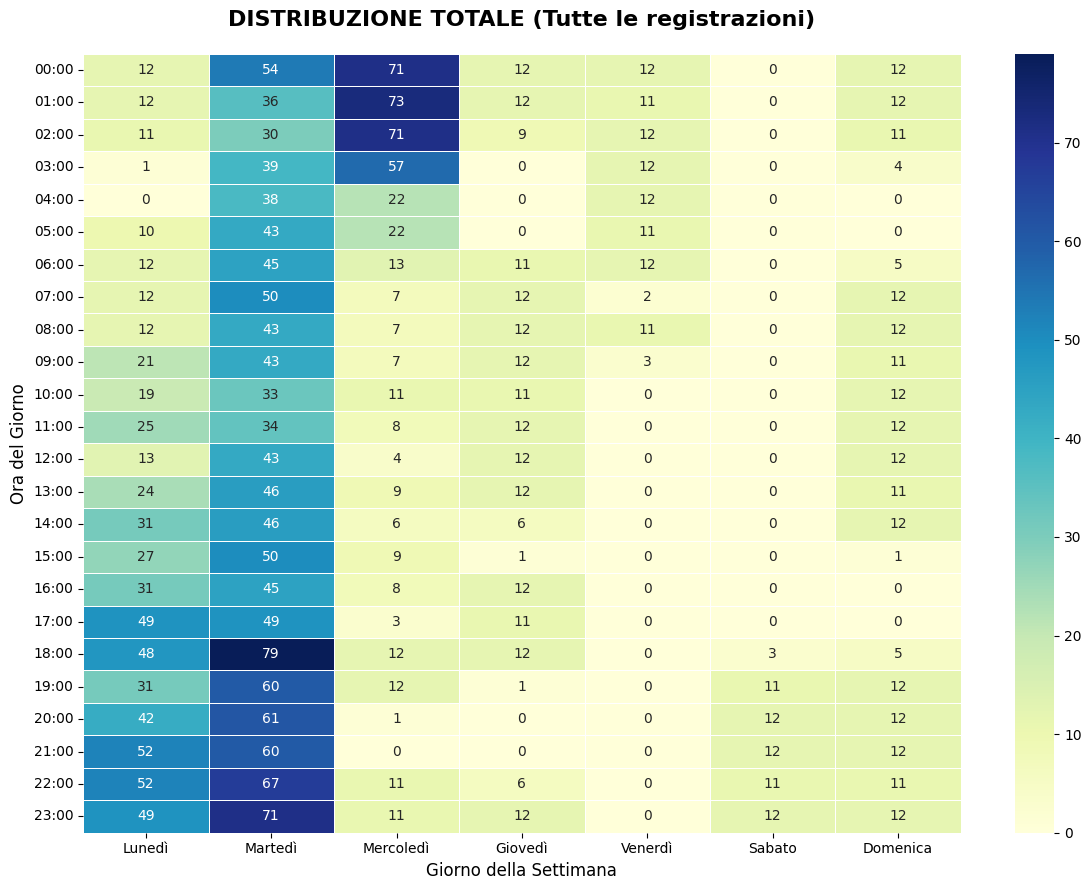

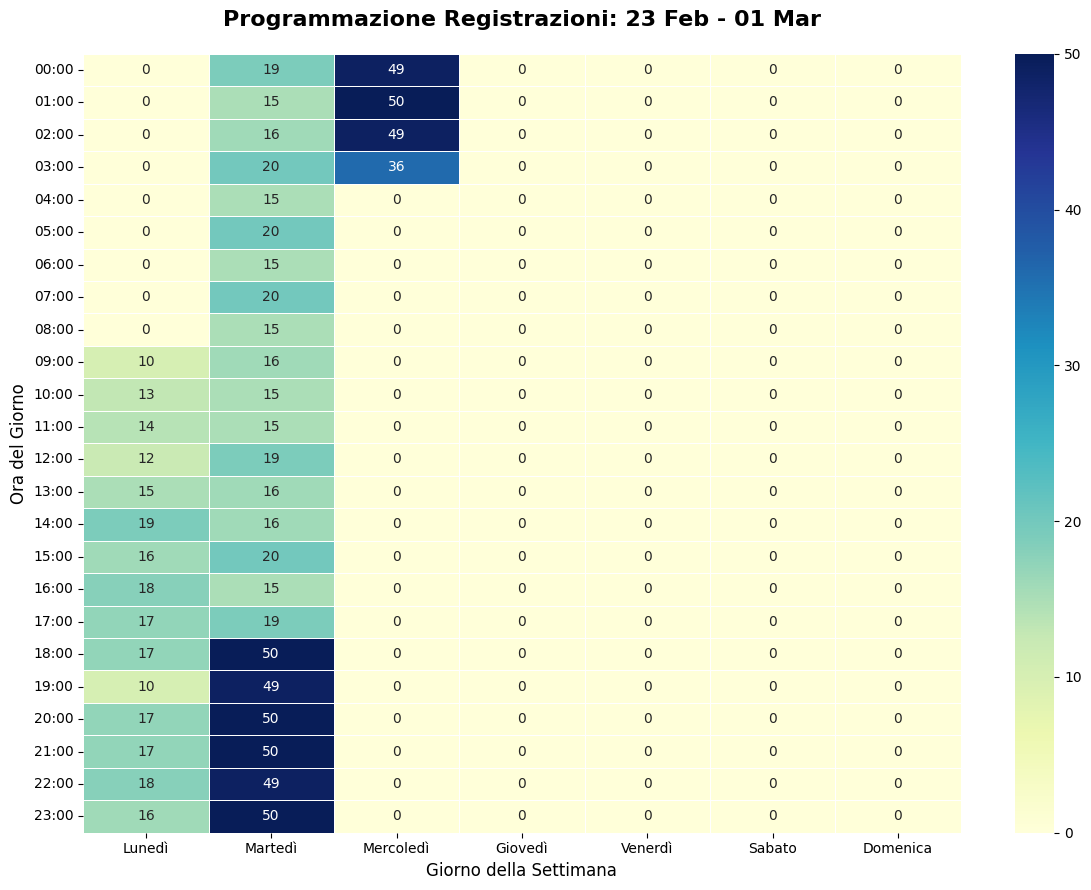

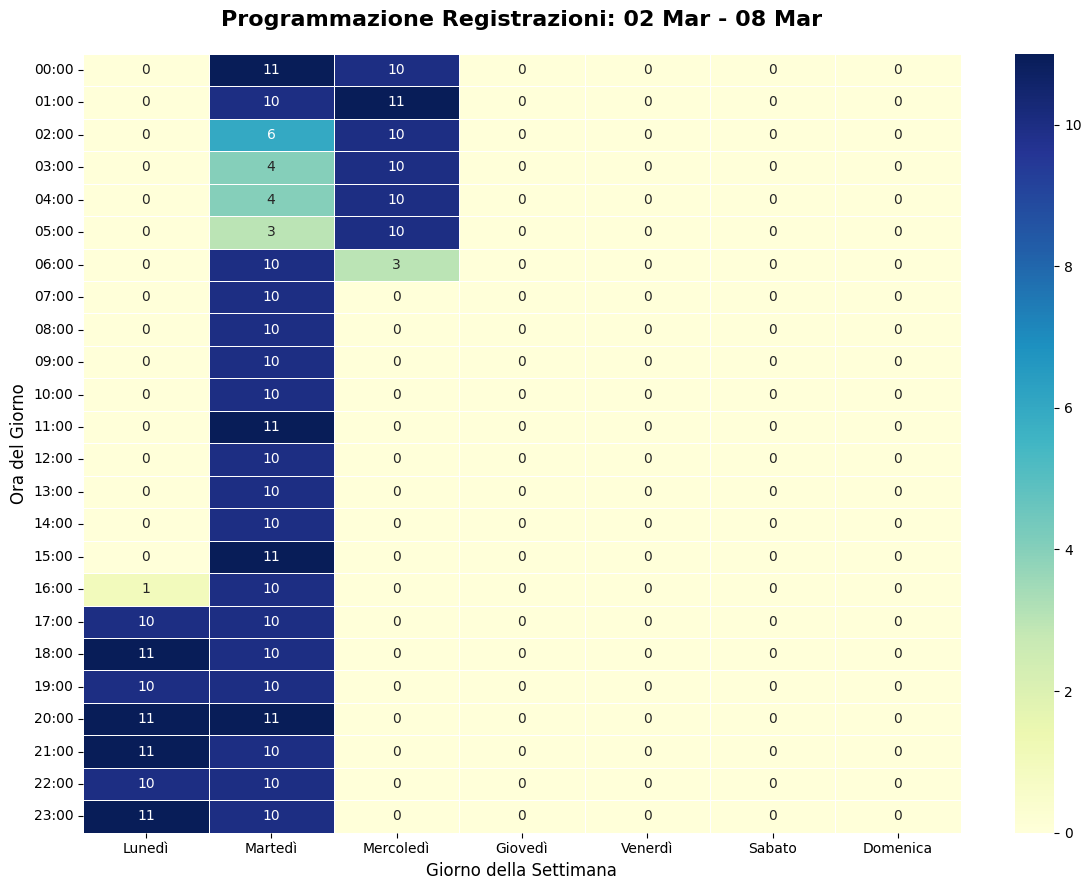

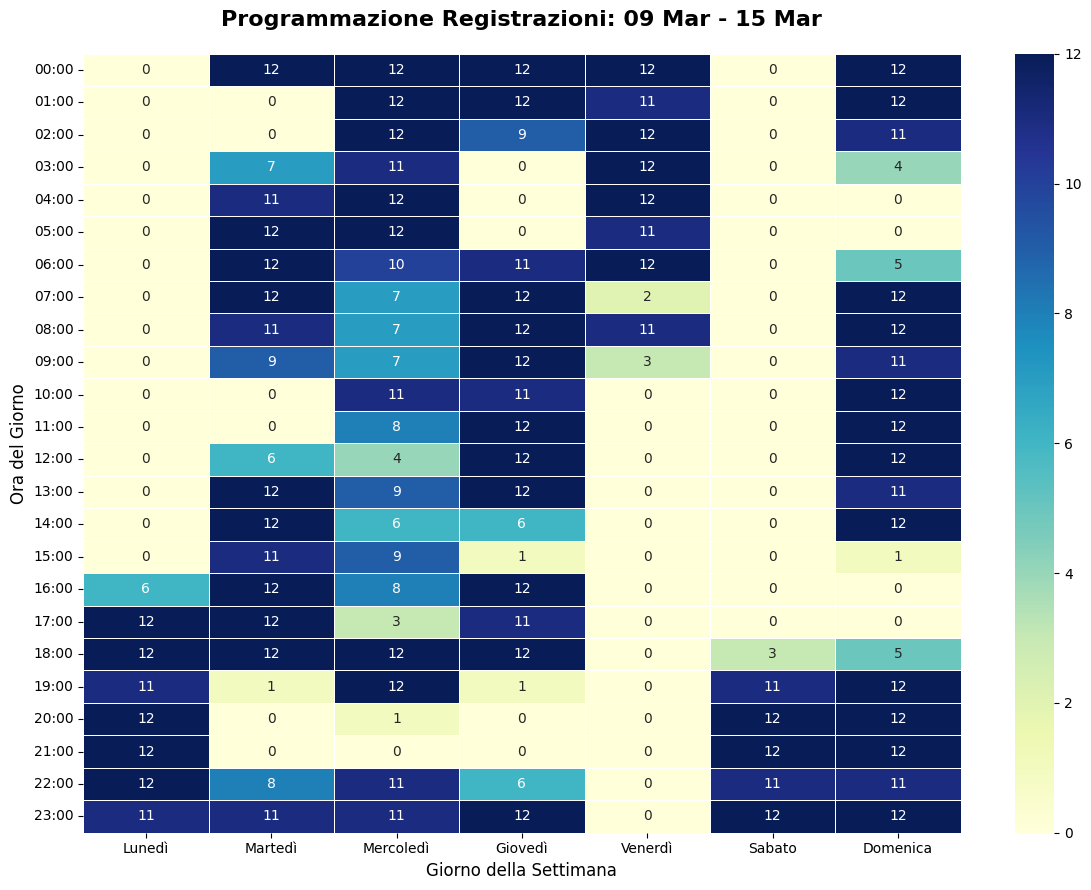

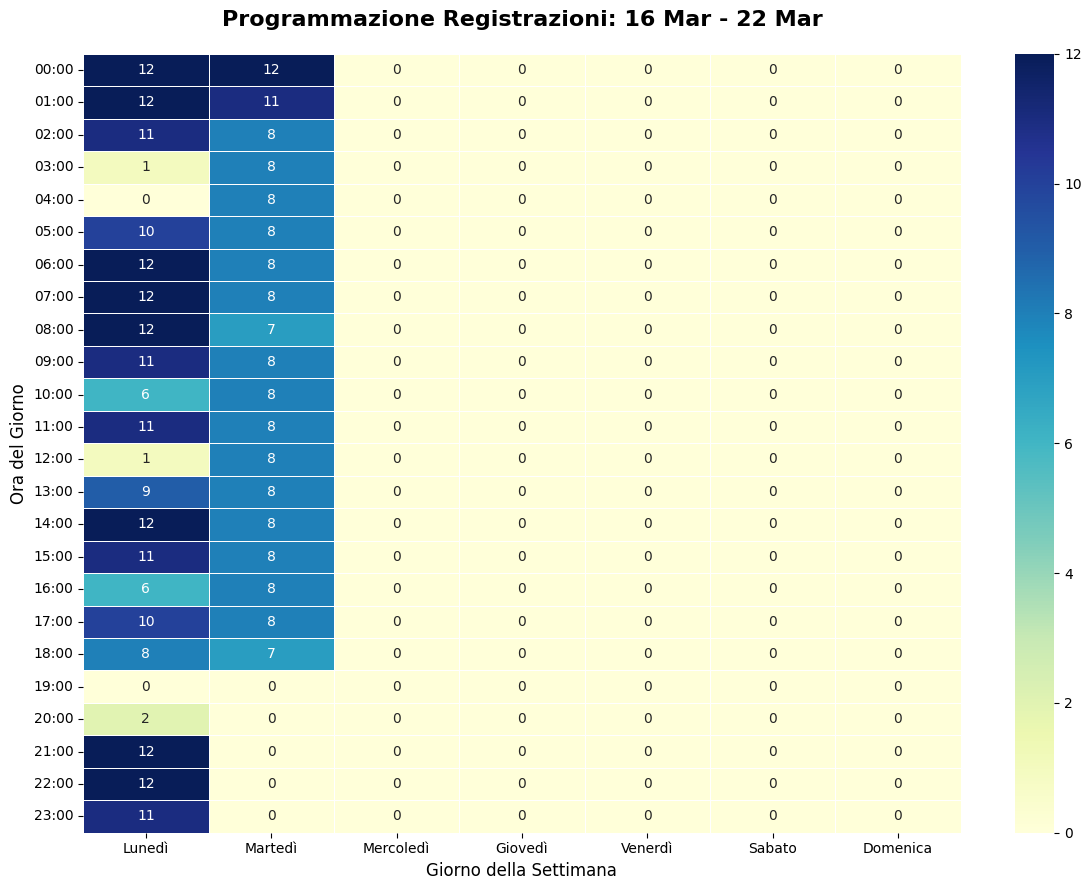

In [8]:

def plot_registration_scheduling(audio_df):
    # 1. Preparazione dati
    df = audio_df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)
    
    # 2. Creazione etichette in Italiano
    traduzione_giorni = {
        'Monday': 'Lunedì', 'Tuesday': 'Martedì', 'Wednesday': 'Mercoledì',
        'Thursday': 'Giovedì', 'Friday': 'Venerdì', 'Saturday': 'Sabato', 'Sunday': 'Domenica'
    }
    
    df['Giorni'] = df['timestamp'].dt.day_name().map(traduzione_giorni)
    df['Ore'] = df['timestamp'].dt.hour.astype(str).str.zfill(2) + ":00"
    
    # 3. CALCOLO RANGE SETTIMANA (es. 02 Mar - 08 Mar)
    # Troviamo il lunedì della settimana per ogni riga
    df['monday'] = df['timestamp'] - pd.to_timedelta(df['timestamp'].dt.dayofweek, unit='D')
    # Troviamo la domenica della settimana
    df['sunday'] = df['monday'] + pd.to_timedelta(6, unit='D')
    
    # Formattiamo la label: "02 Mar - 08 Mar"
    df['week_range'] = (df['monday'].dt.strftime('%d %b') + " - " + 
                        df['sunday'].dt.strftime('%d %b'))
    
    # Ordinamento assi
    giorni_it = ['Lunedì', 'Martedì', 'Mercoledì', 'Giovedì', 'Venerdì', 'Sabato', 'Domenica']
    ore_ordinate = [f"{str(i).zfill(2)}:00" for i in range(24)]

    def draw_heatmap(data_pivot, titolo):
        plt.figure(figsize=(12, 9))
        sns.heatmap(data_pivot, annot=True, fmt='.0f', cmap="YlGnBu", cbar=True, linewidths=.5)
        plt.title(titolo, fontsize=16, weight='bold', pad=20)
        plt.xlabel('Giorno della Settimana', fontsize=12)
        plt.ylabel('Ora del Giorno', fontsize=12)
        plt.tight_layout()
        plt.show()

    # --- PARTE 1: HEATMAP UNIFICATA ---
    pivot_all = df.pivot_table(index='Ore', columns='Giorni', 
                               values='filename', aggfunc='count')
    pivot_all = pivot_all.reindex(index=ore_ordinate, columns=giorni_it).fillna(0)
    
    draw_heatmap(pivot_all, 'DISTRIBUZIONE TOTALE (Tutte le registrazioni)')

    # --- PARTE 2: HEATMAP PER SETTIMANA CON DATE ---
    # Ordiniamo le settimane cronologicamente basandoci sulla data del lunedì
    settimane_ordinate = df.sort_values('monday')['week_range'].unique()
    
    for settimana in settimane_ordinate:
        df_settimana = df[df['week_range'] == settimana]
        
        pivot_sett = df_settimana.pivot_table(index='Ore', columns='Giorni', 
                                               values='filename', aggfunc='count')
        pivot_sett = pivot_sett.reindex(index=ore_ordinate, columns=giorni_it).fillna(0)
        
        draw_heatmap(pivot_sett, f'Programmazione Registrazioni: {settimana}')


plot_registration_scheduling(audiofiles_df)